<a href="https://colab.research.google.com/github/VikaSvyat/DI_Bootcamp/blob/main/colab/MiniProject_PredictingHeartDisease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving UCI Heart Disease Data.zip to UCI Heart Disease Data.zip


In [4]:
!unzip 'UCI Heart Disease Data.zip'

Archive:  UCI Heart Disease Data.zip
  inflating: heart_disease_uci.csv   


In [8]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

print("All imports loaded!")

All imports loaded!


In [10]:
!ls

 heart_disease_uci.csv	 sample_data  'UCI Heart Disease Data.zip'


| Поле         | Что означает             | Пояснение                                                                                   |
| ------------ | ------------------------ | ------------------------------------------------------------------------------------------- |
| **age**      | возраст                  | Возраст пациента в годах                                                                    |
| **sex**      | пол                      | `Male` / `Female`                                                                           |
| **dataset**  | источник данных          | Больница или страна, где собирались данные (Cleveland, Hungary, Switzerland, VA Long Beach) |
| **cp**       | тип боли в груди         | Chest Pain Type                                                                             |
| **trestbps** | давление в покое         | Resting Blood Pressure (мм рт. ст.)                                                         |
| **chol**     | холестерин               | Serum Cholesterol (mg/dl)                                                                   |
| **fbs**      | сахар натощак            | Fasting Blood Sugar > 120 mg/dl (True / False)                                              |
| **restecg**  | ЭКГ в покое              | Resting Electrocardiogram results                                                           |
| **thalch**   | максимальный пульс       | Maximum heart rate achieved                                                                 |
| **exang**    | стенокардия при нагрузке | Exercise induced angina (Yes / No)                                                          |
| **oldpeak**  | депрессия ST             | Изменение сегмента ST при нагрузке                                                          |
| **slope**    | наклон ST                | Slope of peak exercise ST segment                                                           |
| **ca**       | количество сосудов       | Number of major vessels detected by fluoroscopy                                             |
| **thal**     | результат теста thallium | Тип нарушения кровоснабжения                                                                |
| **num**      | диагноз                  | Наличие сердечного заболевания                                                              |


In [30]:
# Load data
df = pd.read_csv('heart_disease_uci.csv')
# bc_df = pd.DataFrame(data.data, columns=data.feature_names)
# bc_df['diagnosis'] = data.target  # 0 = malignant, 1 = benign
print(df.shape)
print(df.info())
print(df.isnull().sum())
df.head()

(920, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fb

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [31]:
#Handling missing values

#ca has ~66% missing values, so I remove it
df = df.drop(columns=['ca'])

#missing numerical values fill with median
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

#Handle missing categorical values - fill with the most frequent value (mode).
cat_cols = ['fbs', 'restecg', 'exang', 'slope', 'thal', 'cp']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [32]:
#Convert target variable to binary

# In this dataset:
# 0 = no heart disease  1–4 = heart disease
# I convert it to 0 / 1.

df['num'] = (df['num'] > 0).astype(int)

In [33]:
# EDA results
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       920 non-null    bool   
 8   restecg   920 non-null    object 
 9   thalch    920 non-null    float64
 10  exang     920 non-null    bool   
 11  oldpeak   920 non-null    float64
 12  slope     920 non-null    object 
 13  thal      920 non-null    object 
 14  num       920 non-null    int64  
dtypes: bool(2), float64(4), int64(3), object(6)
memory usage: 95.4+ KB


,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


In [34]:
# Part B: Preprocessing & Models
# 1. Separate features (X) and target (y)

X = df.drop('num', axis=1)
y = df['num'] # 0 = no heart disease  1 = heart disease

print(f"Dataset: {len(df)} samples, {X.shape[1]} features")
print(f"Heart Disease rate: {y.mean():.1%}")

Dataset: 920 samples, 14 features
Heart Disease rate: 55.3%


In [36]:
# 2. train_test_split
# Split → Scale → Train → Evaluate (the complete pipeline)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#3. Encode categorical variables
# I do it after splitting to not showing test data to the model
X_train = pd.get_dummies(X_train, drop_first=True).astype(int)
X_test = pd.get_dummies(X_test, drop_first=True).astype(int)
# Align columns for the same set and order
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# 4. StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on TRAINING
X_test_scaled = scaler.transform(X_test)        # ONLY transform on TEST

print("\nFirst patient BEFORE scaling:")
print(f"  {X_train.iloc[0].to_dict()}")
print(f"\nFirst patient AFTER scaling:")
scaled_row = dict(zip(X_train.columns, X_train_scaled[0].round(3)))
print(f"  {scaled_row}")
print(f"\nColumn means (should be ~0): {X_train_scaled.mean(axis=0).round(4)}")
print(f"Column stds  (should be ~1): {X_train_scaled.std(axis=0).round(4)}")



First patient BEFORE scaling:
  {'id': 641, 'age': 53, 'trestbps': 160, 'chol': 0, 'fbs': 0, 'thalch': 122, 'exang': 1, 'oldpeak': 0, 'sex_Male': 1, 'dataset_Hungary': 0, 'dataset_Switzerland': 1, 'dataset_VA Long Beach': 0, 'cp_atypical angina': 0, 'cp_non-anginal': 1, 'cp_typical angina': 0, 'restecg_normal': 0, 'restecg_st-t abnormality': 0, 'slope_flat': 1, 'slope_upsloping': 0, 'thal_normal': 0, 'thal_reversable defect': 1}

First patient AFTER scaling:
  {'id': np.float64(0.683), 'age': np.float64(-0.063), 'trestbps': np.float64(1.56), 'chol': np.float64(-1.858), 'fbs': np.float64(-0.415), 'thalch': np.float64(-0.627), 'exang': np.float64(1.302), 'oldpeak': np.float64(-0.676), 'sex_Male': np.float64(0.525), 'dataset_Hungary': np.float64(-0.672), 'dataset_Switzerland': np.float64(2.598), 'dataset_VA Long Beach': np.float64(-0.533), 'cp_atypical angina': np.float64(-0.483), 'cp_non-anginal': np.float64(1.846), 'cp_typical angina': np.float64(-0.23), 'restecg_normal': np.float64(-1

In [ ]:
# 5. Train & evaluate:

In [39]:
#    LogisticRegression

logreg = LogisticRegression(max_iter=1000)    # 1. Create
logreg.fit(X_train_scaled, y_train)           # 2. Train
y_pred_logreg = logreg.predict(X_test_scaled) # 3. Predict
print("MODEL TRAINED!")

comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_logreg[:10],
    'Match': ['MATCH' if a == p else 'NOT' for a, p in zip(y_test.values[:10], y_pred_logreg[:10])]
})

print()
print("First 10 predictions vs actual:")
display(comparison)

correct = (y_pred_logreg == y_test.values).sum()
total = len(y_test)

print()
print(f"Overall: {correct} correct out of {total} ({correct/total*100:.1f})%")
print(f"Predicted {y_pred_logreg.sum()} Heart Disease - actual {y_test.sum()} Heart Disease")

MODEL TRAINED!

First 10 predictions vs actual:


,Actual,Predicted,Match
0,1,0,NOT
1,1,1,MATCH
2,1,1,MATCH
3,1,1,MATCH
4,0,1,NOT
5,0,1,NOT
6,0,1,NOT
7,1,1,MATCH
8,0,0,MATCH
9,1,1,MATCH



Overall: 156 correct out of 184 (84.8)%
Predicted 112 Heart Disease - actual 102 Heart Disease


1. ACCURACY
  0.8478 (84.8%)
  156 out of 184 predictions correct.
2. Confusion Matrix


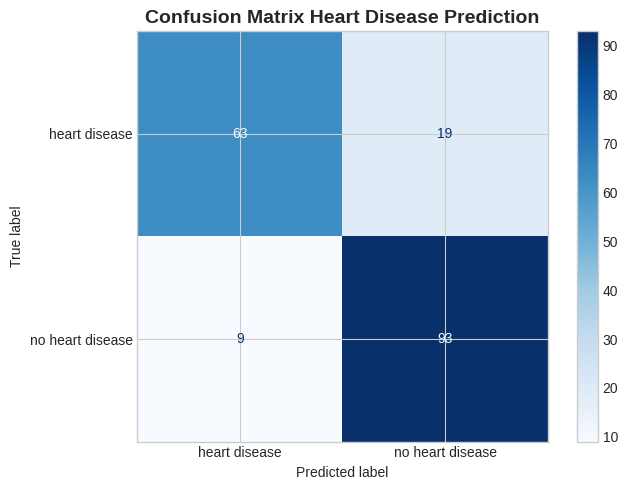


                  precision    recall  f1-score   support

   heart disease       0.88      0.77      0.82        82
no heart disease       0.83      0.91      0.87       102

        accuracy                           0.85       184
       macro avg       0.85      0.84      0.84       184
    weighted avg       0.85      0.85      0.85       184



In [41]:
# A confusion matrix and classification report for model evaluation
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score)

# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred_logreg)
print("1. ACCURACY")
print(f"  {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"  {int(accuracy * len(y_test))} out of {len(y_test)} predictions correct.")

# 2. Confusion matrix
print("2. Confusion Matrix")
fix, ax = plt.subplots(figsize=(7,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_logreg, display_labels=['heart disease', 'no heart disease'], cmap='Blues', ax=ax
)
ax.set_title("Confusion Matrix Heart Disease Prediction", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print()
print(classification_report(y_test, y_pred_logreg, target_names=['heart disease', 'no heart disease']))


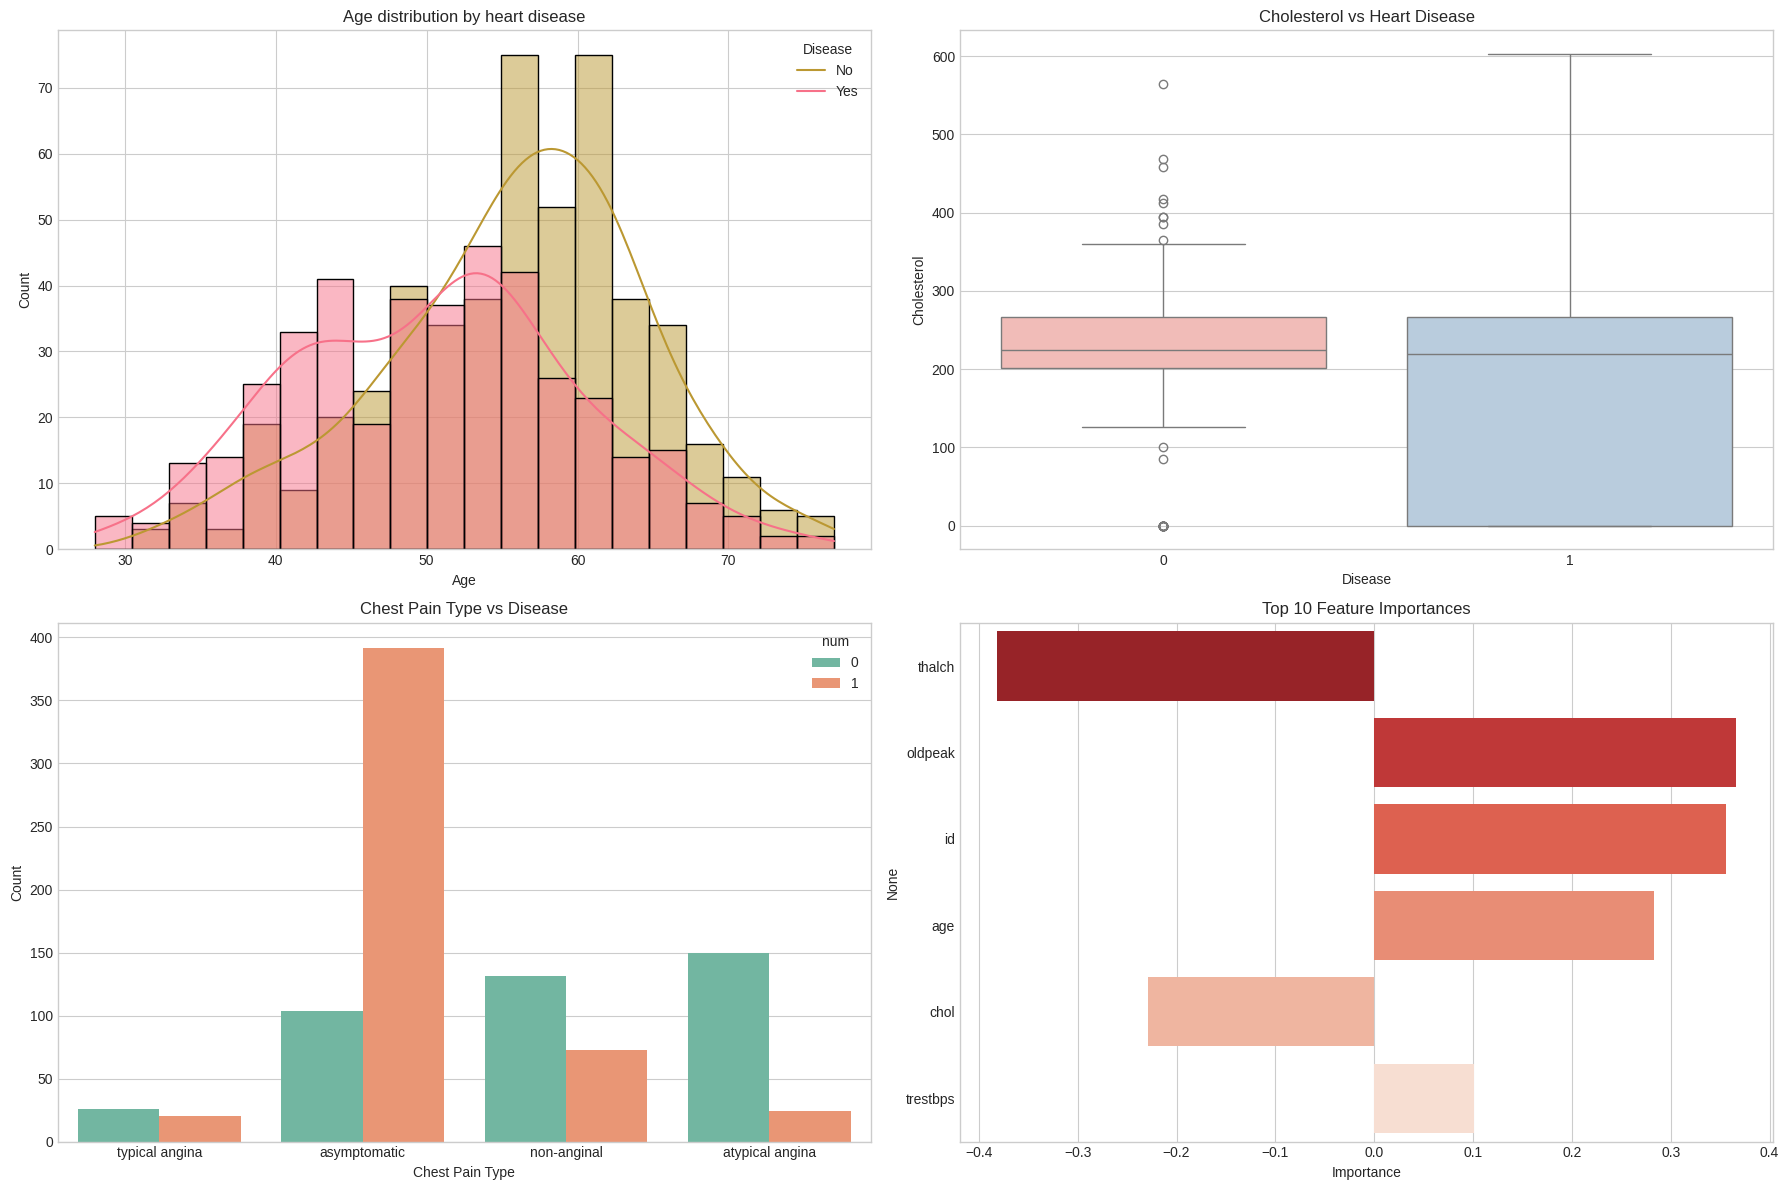

In [62]:
plt.figure(figsize=(18,12))

# 4.1 Scatter plot Age vs Max Heart Rate
plt.subplot(2,2,1)
sns.histplot(data=df, x='age', hue='num', bins=20, kde=True)

plt.title('Age distribution by heart disease')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Disease', labels=['No','Yes'])

# 4.2 Boxplot Cholesterol vs Disease
plt.subplot(2,2,2)
sns.boxplot(data=df, x='num', y='chol', palette='Pastel1')
plt.title('Cholesterol vs Heart Disease')
plt.xlabel('Disease')
plt.ylabel('Cholesterol')

# 4.3 Countplot Chest Pain type vs Disease
plt.subplot(2,2,3)
sns.countplot(data=df, x='cp', hue='num', palette='Set2')
plt.title('Chest Pain Type vs Disease')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')

# 4.4 Feature Importance (Top 10)
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.drop('num')
correlations = df[numeric_cols].corrwith(df['num']).sort_values(key=abs, ascending=False)
# Take top 10 correlated features
top_features = correlations.head(10)
plt.subplot(2,2,4)
sns.barplot(x=top_features.head(10).values, y=top_features.head(10).index, palette='Reds_r')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')

plt.tight_layout()
plt.show()